# Librería

In [1]:
# ==========================================
# 1. Cargamos los imports
# ==========================================

# Librerías base para manejo de datos y computación numérica
import numpy as np       # Álgebra lineal y manejo de arrays
import pandas as pd      # Estructuras de datos y análisis de tablas
import matplotlib.pyplot as plt  # Visualización y creación de gráficos
import random            # Generación de números aleatorios nativos de Python

# Herramientas de preprocesamiento de Scikit-Learn
from sklearn.model_selection import train_test_split  # Para dividir el dataset en entrenamiento y prueba

# Framework de Deep Learning: TensorFlow y Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer      # Para convertir texto en tokens numéricos
from tensorflow.keras.preprocessing.sequence import pad_sequences # Para normalizar la longitud de las secuencias
from tensorflow.keras.models import Sequential                 # Para crear modelos capa por capa
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Input # Capas específicas para PLN y redes neuronales
from tensorflow.keras.optimizers import Adam                   # Algoritmo de optimización para el entrenamiento

# ==========================================
# 2. Configuración de Reproducibilidad
# ==========================================

# Fijamos las semillas aleatorias para que los resultados sean consistentes 
# cada vez que se ejecute el código (evita variaciones por azar).
np.random.seed(42)       # Semilla para NumPy
tf.random.set_seed(42)   # Semilla para TensorFlow/Keras
random.seed(42)          # Semilla para el módulo random de Python

Creamos un dataset síntetico de clasificación.

In [4]:
# =========================================================
# Generación de Dataset Sintético para Clasificación de Texto
# =========================================================

# Listado de núcleos de la oración (sustantivos sobre los que se opina)
sujetos = [
    "la clase", "el curso", "la presentacion", "el sistema", "el modelo", 
    "la red", "la explicacion", "el resultado", "la practica", "la sesion"
]

# Nexos de unión (verbos copulativos) para estructurar la opinión
verbos = [
    "fue", "estuvo", "resulto", "parecio"
]

# --- Etiquetas de Clase (Labels) ---

# Adjetivos para generar ejemplos de la CLASE POSITIVA (1)
positivos = [
    "excelente", "clara", "util", "ordenada", "brillante",
    "precisa", "interesante", "estable", "correcta", "eficiente"
]

# Adjetivos para generar ejemplos de la CLASE NEGATIVA (0)
negativos = [
    "terrible", "confusa", "mala", "aburrida", "inestable", "incorrecta",
    "deficiente", "pesada", "desordenada", "pobre"
]

# Contexto adicional para aumentar la complejidad y longitud de las frases
complementos = [
    "para el grupo", "durante la sesion", "en esta practica", "para el analisis",
    "segun los resultados", "en el laboratorio", "durante la clase", "para este problema",
    "en la evaluacion final", "segun el experimento"
]

In [8]:
# Inicializamos listas vacías para almacenar los datos generados
frases = []    # Contendrá el texto de las oraciones
etiquetas = [] # Contendrá las etiquetas (1 para positivo, 0 para negativo)

Generacipon de ejemplos **POSITIVOS**

In [12]:
# ==========================================
# Generación de ejemplos POSITIVOS
# ==========================================
for _ in range(300):
    # Selección aleatoria de componentes para construir una opinión favorable
    sujeto = random.choice(sujetos)
    verbo = random.choice(verbos)
    adj = random.choice(positivos)
    complemento = random.choice(complementos)
    
    # Construcción de la frase usando f-strings
    frase = f"{sujeto} {verbo} {adj} {complemento}"
    
    frases.append(frase)
    etiquetas.append(1)  # Asignamos la clase 1 (Positivo)

Generación de ejemplos **NEGATIVOS**

In [16]:
# ==========================================
# Generación de ejemplos NEGATIVOS
# ==========================================
for _ in range(300):
    # Selección aleatoria de componentes para construir una opinión desfavorable
    sujeto = random.choice(sujetos)
    verbo = random.choice(verbos)
    adj = random.choice(negativos)
    complemento = random.choice(complementos)
    
    # Construcción de la frase
    frase = f"{sujeto} {verbo} {adj} {complemento}"
    
    frases.append(frase)
    etiquetas.append(0)  # Asignamos la clase 0 (Negativo)

Creación del dataframe y estructuración

In [21]:
# ==========================================
# Creación del DataFrame y Estructuración
# ==========================================

# Consolidamos las listas 'frases' y 'etiquetas' en un objeto DataFrame.
# Esto nos permite manejar los datos como una tabla (filas y columnas).
df = pd.DataFrame({
    "frase": frases,      # Columna de entrada (Features / X)
    "etiqueta": etiquetas  # Columna de salida (Target / y)
})
df

,frase,etiqueta
0,el curso fue brillante para el analisis,1
1,el sistema estuvo clara en la evaluacion final,1
2,el curso parecio excelente para el grupo,1
3,el curso estuvo ordenada en la evaluacion final,1
4,la sesion fue correcta para el analisis,1
...,...,...
595,la red parecio deficiente en esta practica,0
596,el modelo parecio mala en la evaluacion final,0
597,el resultado estuvo aburrida segun los resultados,0
598,la presentacion parecio terrible en la evaluac...,0


Mezcla y verificación del Dataset

In [26]:
# ==========================================
# Mezcla y Verificación del Dataset
# ==========================================

# Mezclamos el DataFrame de forma aleatoria (Shuffle).
# frac=1 indica que queremos el 100% de las filas.
# reset_index(drop=True) reorganiza los índices del 0 al 599 tras el desorden.
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Visualizamos una muestra inicial para confirmar que el texto y las etiquetas coinciden
print("### Muestra del Dataset (Primeras 5 filas):")
print(df.head())

# Verificación de la cantidad total de datos generados
print("\nTotal de ejemplos:", len(df))

# Comprobación de balance de clases. 
# Es crucial para asegurar que el modelo no aprenda más de una categoría que de otra.
print("\nBalance de clases:")
print(df["etiqueta"].value_counts())

### Muestra del Dataset (Primeras 5 filas):
                                            frase  etiqueta
0          la clase fue ordenada para el analisis         1
1    la clase parecio mala en la evaluacion final         0
2    el resultado fue util en la evaluacion final         1
3   la practica parecio precisa en el laboratorio         1
4  el modelo resulto interesante en esta practica         1

Total de ejemplos: 600

Balance de clases:
etiqueta
1    300
0    300
Name: count, dtype: int64


**PARTICIÓN DEL DATASET: ENTRENAMIENTO VS. PRUEBA**

In [29]:
# Convertimos las columnas del DataFrame a listas nativas de Python.
# Esto suele facilitar el procesamiento en las capas de Tokenización de Keras.
X = df["frase"].tolist()    # Características (Texto de entrada)
y = df["etiqueta"].tolist() # Etiquetas (Target / Clasificación)

# Dividimos los datos utilizando una proporción 80/20.
# - test_size=0.2: Reserva el 20% de los datos para evaluar el modelo (hold-out set).
# - random_state=42: Garantiza que la división sea reproducible.
# - stratify=y: Mantiene la proporción de clases (50/50) tanto en train como en test,
#   evitando que un conjunto se quede con más ejemplos de una clase que el otro.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Resumen de la división
print(f"✅ Tamaño del conjunto de entrenamiento: {len(X_train)} frases")
print(f"✅ Tamaño del conjunto de prueba:        {len(X_test)} frases")

✅ Tamaño del conjunto de entrenamiento: 480 frases
✅ Tamaño del conjunto de prueba:        120 frases


**PROCESO DE TOKENIZACIÓN Y CREACIÓN DEL VOCABULARIO**

In [38]:
# Inicializamos el Tokenizer de Keras.
# oov_token="<OOV>": (Out Of Vocabulary) Es una etiqueta especial para palabras 
# que el modelo no haya visto en el entrenamiento pero que aparezcan en el test.
tokenizer = Tokenizer(oov_token="<OOV>")

# El tokenizador analiza X_train para construir el diccionario de frecuencias.
# Crea un mapeo único donde cada palabra se convierte en un número entero.
tokenizer.fit_on_texts(X_train)

# Extraemos el diccionario (palabra -> índice) generado.
word_index = tokenizer.word_index

# --- Inspección del Vocabulario ---

# El tamaño del vocabulario es fundamental para configurar la capa de Embedding.
print(f"📊 Tamaño total del vocabulario: {len(word_index)} palabras\n")

print("\n🔍 Muestra de los primeros 25 tokens del diccionario:")
# Encabezados de la tabla
print(f"{'Índice':<10} | {'Palabra':<20}")
print("-" * 35)

# Recorremos el word_index y lo imprimimos con formato de tabla
# Usamos < para alinear a la izquierda y el número para el ancho de la columna
for palabra, indice in list(word_index.items())[:25]:
    print(f"{indice:<10} | {palabra:<20}")

print("-" * 35)

📊 Tamaño total del vocabulario: 52 palabras


🔍 Muestra de los primeros 25 tokens del diccionario:
Índice     | Palabra             
-----------------------------------
1          | <OOV>               
2          | la                  
3          | el                  
4          | en                  
5          | para                
6          | resulto             
7          | fue                 
8          | parecio             
9          | estuvo              
10         | segun               
11         | sesion              
12         | practica            
13         | durante             
14         | clase               
15         | modelo              
16         | este                
17         | problema            
18         | evaluacion          
19         | final               
20         | los                 
21         | resultados          
22         | sistema             
23         | explicacion         
24         | resultado           
25         | ex

**SECUENCIACIÓN Y NORMALIZACIÓN (PADDING)**

In [41]:
# Transformamos las frases (texto) en listas de números enteros 
# basándonos en el diccionario creado por el Tokenizer.
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

In [49]:
# --- Verificación de la transformación ---
print(f"Frase original (texto): {X_train[0]}...") 
print(f"Frase convertida (números): {X_train_seq[0]}...")

Frase original (texto): la sesion fue aburrida para el grupo...
Frase convertida (números): [2, 11, 7, 48, 5, 3, 30]...


In [51]:
# Calculamos la longitud máxima observada en cada conjunto
# La list comprehension dentro de max() recorre cada secuencia y mide su len()
max_train = max([len(x) for x in X_train_seq])
max_test = max([len(x) for x in X_test_seq])

# Imprimimos los resultados para definir nuestro maxlen del padding
print(f"Longitud máxima en entrenamiento: {max_train}")
print(f"Longitud máxima en prueba: {max_test}")

Longitud máxima en entrenamiento: 8
Longitud máxima en prueba: 8


> **Nota: Se utiliza siempre la longitud de entrenamiento** para asegurar que el modelo tenga un tamaño de entrada fijo y no "contaminarlo" con información del conjunto de prueba (evitando el Data Leakage). Si una frase de prueba es más larga, simplemente se recorta para ajustarse al estándar que el modelo aprendió.

In [55]:

# Buscamos la longitud de la oración con más palabras
max_len = max(len(seq) for seq in X_train_seq)         # Calcula el tamaño de la frase más larga del corpus
print("\nLongitud máxima encontrada:", max_len)       # Reporta el estándar de ancho para todas las secuencias


Longitud máxima encontrada: 8


**APLICACIÓN DE PADDING**

In [58]:
# Aplicamos Padding (relleno): Como las redes neuronales requieren entradas de 
# tamaño fijo, añadimos ceros al final ("post") de las frases cortas.
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

Observamos las $5$ priemras frases del entrenamiento después de aplicar **padding**

In [60]:
X_train_pad[:5] 

array([[ 2, 11,  7, 48,  5,  3, 30,  0],
       [ 2, 12,  8, 39,  4, 32, 12,  0],
       [ 3, 24,  8, 35,  4,  2, 18, 19],
       [ 2, 29,  8, 40,  5, 16, 17,  0],
       [ 2, 23,  6, 52, 13,  2, 11,  0]])

Observamos el tamaño de <code> X_train_pad </code>

In [63]:
print("Forma de X_train_pad:", X_train_pad.shape)     # Indica el número de frases y la longitud de cada una

Forma de X_train_pad: (480, 8)


In [66]:
# Elegimos un índice para comparar (el primero)
i = 0

print("--- TRANSFORMACIÓN DE UN EJEMPLO ---")

# 1. Frase Original (Texto)
print(f"\n1. FRASE ORIGINAL (X_train):")
print(X_train[i])

# 2. Frase Tokenizada (Lista de números de longitud variable)
print(f"\n2. FRASE TOKENIZADA (X_train_seq):")
print(X_train_seq[i])
print(f"Longitud original: {len(X_train_seq[i])} palabras")

# 3. Frase con Padding (Matriz de longitud fija para la red)
print(f"\n3. FRASE CON PADDING (X_train_pad):")
print(X_train_pad[i])
print(f"Longitud final: {len(X_train_pad[i])} (rellenada con ceros)")

--- TRANSFORMACIÓN DE UN EJEMPLO ---

1. FRASE ORIGINAL (X_train):
la sesion fue aburrida para el grupo

2. FRASE TOKENIZADA (X_train_seq):
[2, 11, 7, 48, 5, 3, 30]
Longitud original: 7 palabras

3. FRASE CON PADDING (X_train_pad):
[ 2 11  7 48  5  3 30  0]
Longitud final: 8 (rellenada con ceros)


In [75]:
# --- Verificación de Dimensiones ---
# La forma (shape) nos indica: (Número de ejemplos, Longitud de la secuencia)
print(f"📐 Forma de X_train_pad: {X_train_pad.shape}")
print(f"📐 Forma de X_test_pad:  {X_test_pad.shape}")
print(f"📏 Longitud máxima de secuencia: {max_len}")

📐 Forma de X_train_pad: (480, 8)
📐 Forma de X_test_pad:  (120, 8)
📏 Longitud máxima de secuencia: 8


**TAMAÑO DEL VOCABULARIO (EMBEDDING)**

In [73]:
# Definimos el tamaño del vocabulario para la capa de Embedding.
# Sumamos +1 porque el índice 0 está reservado para el padding (los ceros).
vocab_size = len(word_index) + 1

**DEFINICIÓN Y ARQUITECTURA DEL MODELO RNN (LSTM)**

In [78]:
# Dimensión del espacio vectorial para las palabras (cada palabra será un vector de 16 números)
embedding_dim = 16

# Inicializamos el modelo secuencial (capa tras capa)
modelo_lstm = Sequential()

# Capa de Entrada: Define la forma de los datos (la longitud máxima de nuestras frases)
modelo_lstm.add(Input(shape=(max_len,)))

# Capa de Embedding: Transforma números enteros en vectores densos con significado semántico.
# mask_zero=True: Ignora los ceros del padding para que no afecten al cálculo de la red.
modelo_lstm.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True
    )
)

# Capa LSTM (Long Short-Term Memory): Capaz de aprender dependencias a largo plazo en el texto.
# recurrent_dropout=0.2: Técnica de regularización para evitar el sobreajuste (overfitting).
modelo_lstm.add(LSTM(16, recurrent_dropout=0.2))

# Capa de Salida: Una neurona con activación Sigmoide para clasificación binaria (0 o 1).
modelo_lstm.add(Dense(1, activation="sigmoid"))

# --- Configuración del Entrenamiento ---

modelo_lstm.compile(
    # Adam: Optimizador eficiente que ajusta dinámicamente la tasa de aprendizaje.
    optimizer=Adam(learning_rate=0.001),
    # binary_crossentropy: Función de pérdida estándar para problemas de "Sí o No".
    loss="binary_crossentropy",
    # accuracy: Métrica para monitorear el porcentaje de aciertos durante el proceso.
    metrics=["accuracy"]
)

# Visualizamos la estructura, el número de neuronas y los parámetros entrenables
modelo_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 8, 16)               │             848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 16)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,977 (11.63 KB)

 Trainable params: 2,977 (11.63 KB)

 Non-trainable params: 0 (0.00 B)

**DEFINICIÓN Y ARQUITECTURA DEL MODELO RNN (GRU)**

In [87]:
# Inicializamos un nuevo modelo secuencial independiente
modelo_gru = Sequential()

# Capa de Entrada: Recibe las secuencias con la longitud máxima definida (max_len)
modelo_gru.add(Input(shape=(max_len,)))

# Capa de Embedding: Mapea los índices de palabras a vectores continuos.
# Utilizamos los mismos hiperparámetros que en el modelo anterior para una comparación justa.
modelo_gru.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True  # Crucial para no procesar los ceros del padding
    )
)

# Capa GRU (Gated Recurrent Unit): 
# A diferencia de la LSTM, tiene una estructura más simplificada (menos puertas internas),
# lo que suele traducirse en un entrenamiento más rápido con un rendimiento similar.
modelo_gru.add(GRU(16, recurrent_dropout=0.2))

# Capa de Salida: Clasificador binario (Salida entre 0 y 1)
modelo_gru.add(Dense(1, activation="sigmoid"))

# --- Configuración del Compilador ---

modelo_gru.compile(
    optimizer=Adam(learning_rate=0.001), # Optimizador adaptativo
    loss="binary_crossentropy",         # Función de error para clasificación binaria
    metrics=["accuracy"]                # Seguimiento del porcentaje de éxito
)

# Resumen de la arquitectura: verás que la GRU tiene menos parámetros que la LSTM
modelo_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 8, 16)               │             848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 16)                  │           1,632 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

**PROCESO DE ENTRENAMIENTO (FIT)**

In [90]:
# Entrenamos el modelo basado en LSTM
# ------------------------------------------------------------------------------
hist_lstm = modelo_lstm.fit(
    X_train_pad,        # Datos de entrenamiento (secuencias con padding)
    np.array(y_train),  # Etiquetas convertidas a formato NumPy
    epochs=20,          # Número de iteraciones completas sobre el dataset
    validation_split=0.2, # Reserva el 20% de los datos de entrenamiento para validar
    verbose=0           # Entrenamiento "silencioso" (sin barras de progreso por época)
)

# Entrenamos el modelo basado en GRU
# ------------------------------------------------------------------------------
hist_gru = modelo_gru.fit(
    X_train_pad,        # Datos de entrenamiento
    np.array(y_train),  # Etiquetas
    epochs=20,          # Mismo número de épocas para una comparativa justa
    validation_split=0.2, # Validación interna para detectar sobreajuste
    verbose=0           # Sin salida de texto durante el proceso
)

**VISUALIZACIÓN DE RESULTADOS: COMPARATIVA DE RENDIMIENTO**

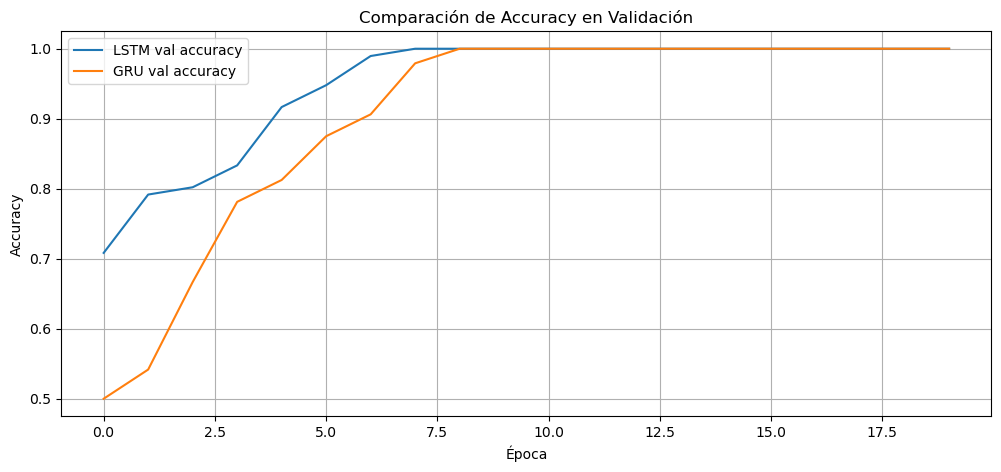

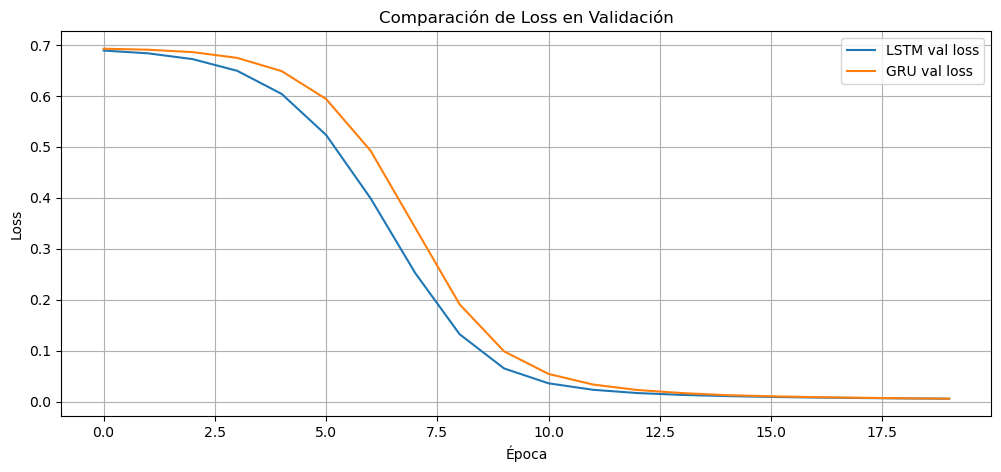

In [95]:
# --- Gráfica de Precisión (Accuracy) ---
# Comparamos qué tan bien predice cada modelo en datos que no vio durante el entrenamiento.
plt.figure(figsize=(12, 5))
plt.plot(hist_lstm.history["val_accuracy"], label="LSTM val accuracy") # Evolución del acierto LSTM
plt.plot(hist_gru.history["val_accuracy"], label="GRU val accuracy")   # Evolución del acierto GRU

plt.title("Comparación de Accuracy en Validación")
plt.xlabel("Época")
plt.ylabel("Accuracy") # Representa el porcentaje de aciertos (0.0 a 1.0)
plt.legend()           # Muestra el cuadro con los nombres de las líneas
plt.grid(True)         # Añade una cuadrícula para facilitar la lectura de valores
plt.show()

# --- Gráfica de Pérdida (Loss) ---
# Comparamos la "distancia" entre la predicción y el valor real. 
# Buscamos que este valor sea lo más bajo posible.
plt.figure(figsize=(12, 5))
plt.plot(hist_lstm.history["val_loss"], label="LSTM val loss") # Evolución del error LSTM
plt.plot(hist_gru.history["val_loss"], label="GRU val loss")   # Evolución del error GRU

plt.title("Comparación de Loss en Validación")
plt.xlabel("Época")
plt.ylabel("Loss")     # Representa la magnitud del error (Binary Cross-Entropy)
plt.legend()
plt.grid(True)
plt.show()

**EVALUACIÓN FINAL CON EL CONJUNTO DE PRUEBA (TEST SET)**

In [98]:
# Evaluamos el modelo LSTM en el conjunto de test (datos nunca vistos)
# .evaluate devuelve una lista donde el índice [0] es el Loss y el [1] es el Accuracy.
resultado_lstm = modelo_lstm.evaluate(X_test_pad, np.array(y_test), verbose=0)

# Evaluamos el modelo GRU bajo las mismas condiciones
resultado_gru = modelo_gru.evaluate(X_test_pad, np.array(y_test), verbose=0)

# --- Reporte de Resultados Finales ---

print("=== RESULTADOS MODELO LSTM ===")
print(f"Pérdida (Loss): {resultado_lstm[0]:.4f}")
print(f"Precisión (Accuracy): {resultado_lstm[1]:.4f}")

print("\n=== RESULTADOS MODELO GRU ===")
print(f"Pérdida (Loss): {resultado_gru[0]:.4f}")
print(f"Precisión (Accuracy): {resultado_gru[1]:.4f}")

=== RESULTADOS MODELO LSTM ===
Pérdida (Loss): 0.0056
Precisión (Accuracy): 1.0000

=== RESULTADOS MODELO GRU ===
Pérdida (Loss): 0.0056
Precisión (Accuracy): 1.0000


**PRUEBA DE INFERENCIA: PREDICCIÓN CON NUEVOS DATOS**

In [103]:
# Definimos una lista de oraciones que el modelo NO ha visto nunca.
# Mezclamos estructuras positivas y negativas para ponerlo a prueba.
frases_nuevas = [
    "el curso estuvo terrible para el grupo",           # Negativa
    "la explicacion resulto clara en el laboratorio",   # Positiva
    "el sistema parecio inestable segun los resultados", # Negativa
    "la practica fue ordenada para este problema",       # Positiva
    "la sesion estuvo confusa en la evaluacion final"    # Negativa
]

# --- Preprocesamiento de las nuevas frases ---
# Es vital aplicar exactamente el mismo proceso que usamos en el entrenamiento:
# 1. Convertir texto a números usando el diccionario ya entrenado (Tokenizer).
seq_nuevas = tokenizer.texts_to_sequences(frases_nuevas)

# 2. Normalizar la longitud con padding para que coincida con la entrada del modelo.
pad_nuevas = pad_sequences(seq_nuevas, maxlen=max_len, padding="post")

# --- Ejecución de Predicciones ---
# Obtenemos la probabilidad de salida para cada modelo.
# Al usar activación sigmoide, los valores cercanos a 1 son "Positivos" y a 0 "Negativos".
pred_lstm = modelo_lstm.predict(pad_nuevas, verbose=0)
pred_gru  = modelo_gru.predict(pad_nuevas, verbose=0)

# --- Visualización de Resultados ---
print("🔍 Predicciones sobre nuevas frases:\n")

for i, frase in enumerate(frases_nuevas):
    print(f"Frase: {frase}")
    # Mostramos la confianza de cada modelo (valor de 0 a 1)
    print(f" LSTM Confianza: {pred_lstm[i][0]:.4f} -> {'POSITIVA' if pred_lstm[i][0] > 0.5 else 'NEGATIVA'}")
    print(f" GRU  Confianza: {pred_gru[i][0]:.4f} -> {'POSITIVA' if pred_gru[i][0] > 0.5 else 'NEGATIVA'}")
    print("-" * 70)

🔍 Predicciones sobre nuevas frases:

Frase: el curso estuvo terrible para el grupo
 LSTM Confianza: 0.0061 -> NEGATIVA
 GRU  Confianza: 0.0073 -> NEGATIVA
----------------------------------------------------------------------
Frase: la explicacion resulto clara en el laboratorio
 LSTM Confianza: 0.9946 -> POSITIVA
 GRU  Confianza: 0.9966 -> POSITIVA
----------------------------------------------------------------------
Frase: el sistema parecio inestable segun los resultados
 LSTM Confianza: 0.0066 -> NEGATIVA
 GRU  Confianza: 0.0115 -> NEGATIVA
----------------------------------------------------------------------
Frase: la practica fue ordenada para este problema
 LSTM Confianza: 0.9946 -> POSITIVA
 GRU  Confianza: 0.9961 -> POSITIVA
----------------------------------------------------------------------
Frase: la sesion estuvo confusa en la evaluacion final
 LSTM Confianza: 0.0039 -> NEGATIVA
 GRU  Confianza: 0.0050 -> NEGATIVA
--------------------------------------------------------